In [82]:
import pandas as pd
import matplotlib.pyplot as plt

In [83]:
data = pd.read_csv('/Users/janduplessis/code/janduplessis883/packages/project-noema/noema/data/noema_data.csv')

In [84]:
data.head()

,time,review,pcn,surgery,origin,review_word_count
0,2024-01-01 10:51:00,Everyone kind and helpful,Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,4.0
1,2024-01-01 15:20:00,Nothing. It was all great,Brompton-Health-PCN,Brompton-Health-PCN,feedback,5.0
2,2024-01-02 07:58:00,"Denise was amazing, kind and helpful. The rece...",Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,23.0
3,2024-01-03 15:19:00,No issues with me,Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,4.0
4,2024-01-04 10:42:00,We have had Very good service from the NHS reg...,Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,22.0


<Axes: xlabel='review_word_count', ylabel='Count'>

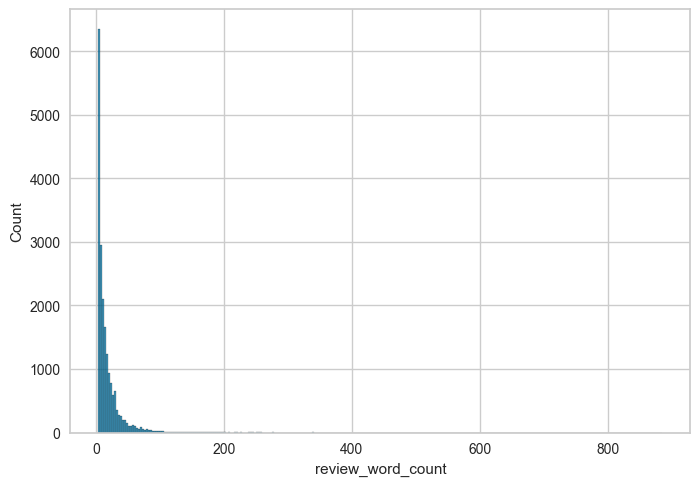

In [85]:
sns.histplot(data['review_word_count'])

In [86]:
review_list = data['review'].tolist()

In [87]:
len(review_list)

20005

In [88]:
from nomic import embed

output = embed.text(
    texts=review_list,
    model='nomic-embed-text-v1.5',
    task_type='search_document',
    inference_mode='local',
)

mode = output['inference_mode']  # 'local'

Embedding texts: 100%|██████████████████████████████████| 20005/20005 [01:37<00:00, 205.79inputs/s]


In [89]:
len(output['embeddings'][0])

768

In [90]:
data['embedding'] = output['embeddings']

In [91]:
data.head()

,time,review,pcn,surgery,origin,review_word_count,embedding
0,2024-01-01 10:51:00,Everyone kind and helpful,Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,4.0,"[0.009078879840672016, -0.019260024651885033, ..."
1,2024-01-01 15:20:00,Nothing. It was all great,Brompton-Health-PCN,Brompton-Health-PCN,feedback,5.0,"[0.02395092509686947, 0.009227578528225422, -0..."
2,2024-01-02 07:58:00,"Denise was amazing, kind and helpful. The rece...",Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,23.0,"[-0.008330773562192917, 0.007228024769574404, ..."
3,2024-01-03 15:19:00,No issues with me,Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,4.0,"[0.02104911580681801, -0.014581732451915741, -..."
4,2024-01-04 10:42:00,We have had Very good service from the NHS reg...,Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,22.0,"[-0.020406799390912056, 0.059436388313770294, ..."


In [92]:
for i, text in enumerate(df['review'].head(30)):
    plt.text(embedding_2d[i,0], embedding_2d[i,1], text[:15], fontsize=8)

NameError: name 'df' is not defined

In [93]:
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import pandas as pd

# 1. Load data
df = pd.read_csv("feedback.csv")  # columns: ['text', 'richness_score']

# 2. Encode
model = SentenceTransformer('all-MiniLM-L6-v2')
df['embeddings'] = df['text'].apply(lambda x: model.encode(x))

# 3. Prepare for training
X = list(df['embeddings'])
y = df['richness_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 4. Train
reg = RandomForestRegressor()
reg.fit(X_train, y_train)

# 5. Evaluate
pred = reg.predict(X_test)
print("MAE:", mean_absolute_error(y_test, pred))

FileNotFoundError: [Errno 2] No such file or directory: 'feedback.csv'

In [ ]:
import re
import numpy as np
import pandas as pd
import nltk
from nltk import word_tokenize, pos_tag
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import MinMaxScaler

In [ ]:
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger_eng')

In [ ]:
# Initialise embedding model
embedder = SentenceTransformer('all-MiniLM-L6-v2')
stop_words = set(stopwords.words('english'))

In [110]:
from tqdm import tqdm
import numpy as np
import pandas as pd
import re
from nltk import pos_tag, word_tokenize
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import pairwise_distances

tqdm.pandas()

def richness_score(df):
    """
    Given a dataframe with 'review' and 'embedding' columns,
    compute linguistic, semantic, and actionability sub-scores + overall richness score.
    """
    results = []

    for _, row in tqdm(df.iterrows(), desc="Calculating richness scores", unit="text", total=df.shape[0]):
        text = row['review']
        embed = np.array(row['embedding'])

        # --- Basic cleaning ---
        clean = re.sub(r'[^a-zA-Z\s]', '', text.lower())
        tokens = [w for w in word_tokenize(clean) if w not in stop_words and len(w) > 2]

        # --- 1. Linguistic Depth ---
        word_count = len(tokens)
        unique_words = len(set(tokens))
        lexical_diversity = unique_words / word_count if word_count else 0
        avg_word_len = np.mean([len(w) for w in tokens]) if tokens else 0
        linguistic_depth = (lexical_diversity + avg_word_len / 10) / 2

        # --- 2. Semantic Density ---
        semantic_density = np.std(embed)

        # --- 3. Actionability / Specificity ---
        tags = pos_tag(tokens)
        verbs = sum(1 for _, t in tags if t.startswith('VB'))
        nouns = sum(1 for _, t in tags if t.startswith('NN'))
        suggestions = sum(1 for w in tokens if w in ['must', 'should', 'need', 'ought', 'has to', 'needs', 'recommend', 'suggest', 'advise', 'improve', 'get better', 'fix', 'change', 'start', 'stop', 'reduce', 'increase', 'continue', 'follow up', 'crucial', 'essential', 'vital', 'important', 'necessary', 'critical', 'priority', 'a must', 'check', 'test', 'examine', 'assess', 're-evaluate', 'look into', 'find a solution', 'wait and see', 'expect', 'demand', 'require', 'insist', 'hope', 'ask', 'listen', 'explain', 'clarify', 'communicate', 'call', 'spend more time'])
        actionability = (verbs + nouns + suggestions) / (word_count + 1e-6)

        results.append([linguistic_depth, semantic_density, actionability])

    # convert list of lists into separate columns
    scores = pd.DataFrame(results, columns=['ling_depth', 'sem_density', 'actionability'])

    # attach new columns to the original dataframe
    df = pd.concat([df.reset_index(drop=True), scores], axis=1)

    # --- Normalise each metric to 0-1 scale ---
    scaler = MinMaxScaler()
    df[['ling_depth', 'sem_density', 'actionability']] = scaler.fit_transform(
        df[['ling_depth', 'sem_density', 'actionability']]
    )

    # --- Combine into overall richness score ---
    df['richness_score'] = (
        0.15 * df['ling_depth'] + 
        0.25 * df['sem_density'] + 
        0.6 * df['actionability']
    )

    return df

In [111]:
new = richness_score(data)

Calculating richness scores: 100%|███████████████████████| 20005/20005 [00:05<00:00, 3898.99text/s]


In [112]:
new.head(100)

,time,review,pcn,surgery,origin,review_word_count,embedding,ling_depth,sem_density,actionability,richness_score
0,2024-01-01 10:51:00,Everyone kind and helpful,Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,4.0,"[0.009078879840672016, -0.019260024651885033, ...",0.480392,0.307524,0.500000,0.478792
1,2024-01-01 15:20:00,Nothing. It was all great,Brompton-Health-PCN,Brompton-Health-PCN,feedback,5.0,"[0.02395092509686947, 0.009227578528225422, -0...",0.470588,0.539731,0.250000,0.301032
2,2024-01-02 07:58:00,"Denise was amazing, kind and helpful. The rece...",Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,23.0,"[-0.008330773562192917, 0.007228024769574404, ...",0.504202,0.518982,0.321429,0.359461
3,2024-01-03 15:19:00,No issues with me,Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,4.0,"[0.02104911580681801, -0.014581732451915741, -...",0.470588,0.378477,0.500000,0.484906
4,2024-01-04 10:42:00,We have had Very good service from the NHS reg...,Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,22.0,"[-0.020406799390912056, 0.059436388313770294, ...",0.455882,0.399583,0.375000,0.385547
...,...,...,...,...,...,...,...,...,...,...,...
95,2024-01-22 13:27:50,Not really. it was fine as it was,Brompton-Health-PCN,Earls-Court-Surgery,do_better,8.0,"[0.06752557307481766, 0.038582317531108856, -0...",0.441176,0.438817,0.000000,0.087999
96,2024-01-22 13:46:03,Dr Emiliani has such a calming demeanour so I ...,Brompton-Health-PCN,Earls-Court-Surgery,feedback,18.0,"[0.03653528168797493, 0.04935086891055107, -0....",0.466912,0.527911,0.312500,0.349482
97,2024-01-22 13:51:18,A bit more flexibility around scheduling appoi...,Brompton-Health-PCN,Earls-Court-Surgery,do_better,9.0,"[-0.022924190387129784, 0.03638822212815285, -...",0.558824,0.309410,0.416667,0.420157
98,2024-01-22 13:51:18,"Caring, understanding and available",Brompton-Health-PCN,Earls-Court-Surgery,feedback,4.0,"[0.012621541507542133, 0.0025192974135279655, ...",0.568627,0.475545,0.333333,0.371084


In [113]:
import seaborn as sns

<Axes: xlabel='richness_score', ylabel='Count'>

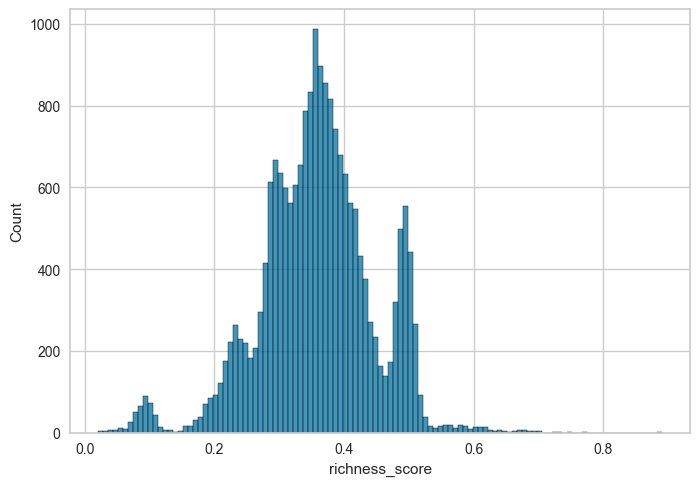

In [114]:
sns.histplot(new['richness_score'])

<Axes: xlabel='ling_depth', ylabel='Count'>

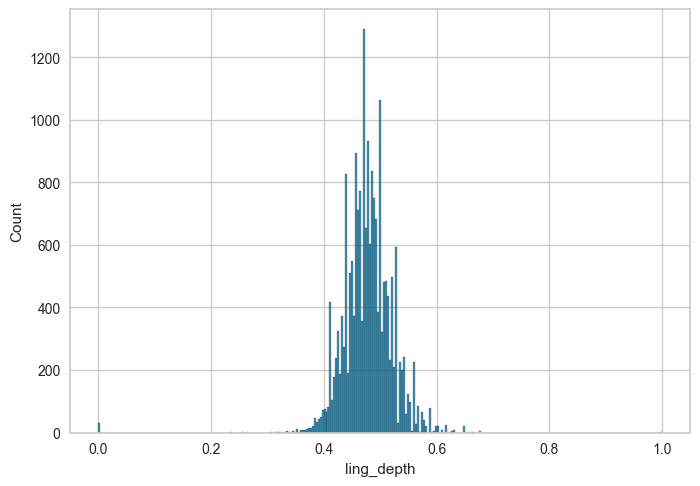

In [115]:
sns.histplot(new['ling_depth'])

<Axes: xlabel='sem_density', ylabel='Count'>

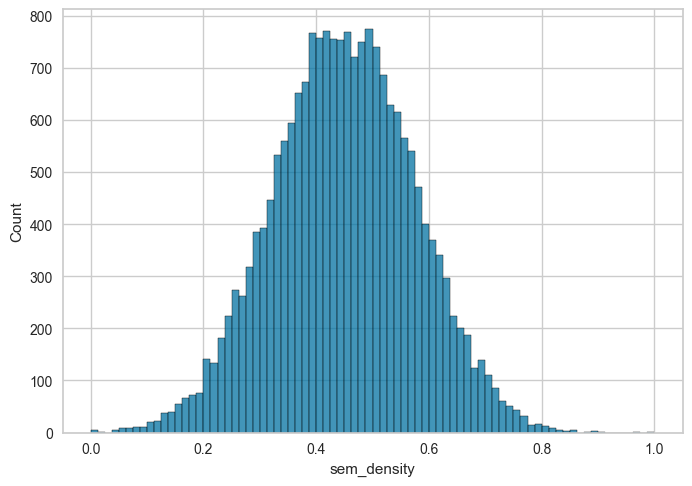

In [116]:
sns.histplot(new['sem_density'])

<Axes: xlabel='actionability', ylabel='Count'>

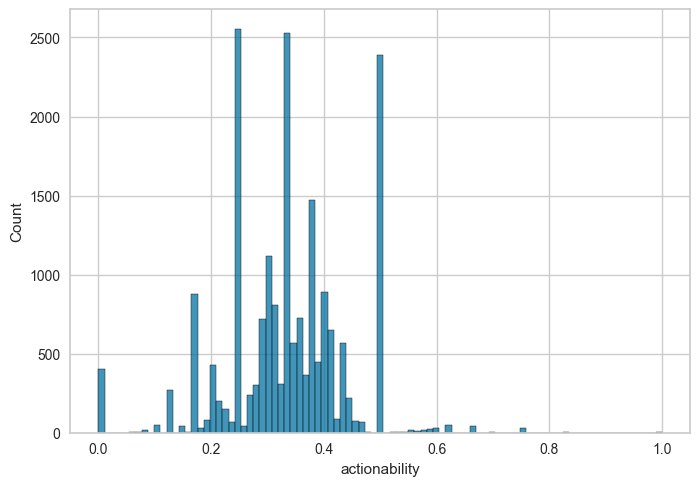

In [117]:
sns.histplot(new['actionability'])

In [ ]:
new5 = new.sample(2000)
import jan883_eda as eda

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import pandas as pd

In [ ]:
# 3. Prepare for training
X = list(new5['embedding'])
y = new5['richness_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
eda.best_regression_models(X, y, test_size=0.2)

In [ ]:
# 4. Train
reg = RandomForestRegressor()
reg.fit(X_train, y_train)

In [ ]:
# 5. Evaluate
pred = reg.predict(X_test)
print("MAE:", mean_absolute_error(y_test, pred))

In [ ]:
new[new['richness_score'] > 0.6]['review'][0]